<a href="https://colab.research.google.com/github/Group-5-herts/Research-Methods/blob/main/Homework1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial homework 1: Pre-processing

In this homework, you will implement some pre-processing steps we learned in class to the California Housing dataset and verify the improvement of model predictions

In [17]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt


### Load california housing dataset

In [18]:

X, y = fetch_california_housing(return_X_y=True, as_frame=True)
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [19]:
y=y.to_frame()
y.head()

,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


### Predictions for dataset without any pre-processing

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

RF = RandomForestRegressor(random_state=42)

RF.fit(X_train,y_train)

predictions_RF = RF.predict(X_test)

mse_RF = mean_squared_error(y_test, predictions_RF)

print("RF MSE = ", mse_RF)

LinReg = LinearRegression()

LinReg.fit(X_train,y_train)

predictions_LR = LinReg.predict(X_test)

mse_LR = mean_squared_error(y_test, predictions_LR)

print("LR MSE = ", mse_LR)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RF MSE =  0.2603403202420427
LR MSE =  0.5369686543372453


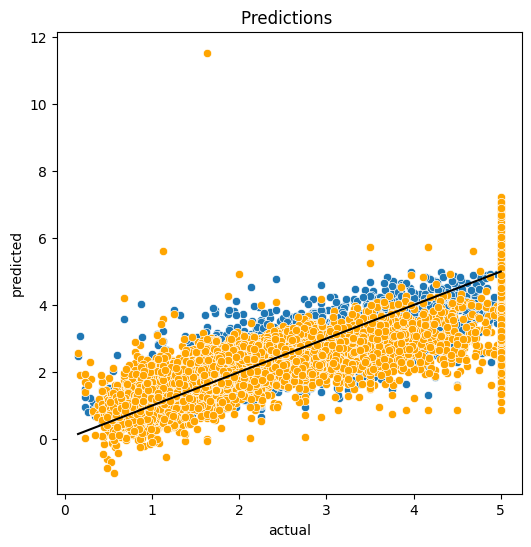

In [21]:
import seaborn as sns
# Create a dataframe to plot
df_RF = pd.DataFrame({'actual': y_test.to_numpy().flatten(), 'predicted': predictions_RF})
df_LR = pd.DataFrame({'actual': y_test.to_numpy().flatten(), 'predicted': predictions_LR.flatten()})

# Plot prediction from pre-processed dataset
plt.figure(figsize=(6, 6))
sns.scatterplot(data=df_RF, x='actual', y='predicted')
sns.scatterplot(data=df_LR, x='actual', y='predicted', color='orange')
plt.plot([min(df_RF['actual']), max(df_RF['actual'])], [min(df_RF['actual']), max(df_RF['actual'])], color='black')
plt.title('Predictions ')
plt.show()

## EXERCISE STARTS HERE

### 1) The Yeo-Johnson transform

Use the Yeo-Johnson transform on this dataset and re-fit both the Random Forest and linear regression models. Calculate the difference in MSE between predictions with the original and transformed dataset for both models.

#### 1a) Apply the Yeo-Johnson transform (to both X and y, but excluding Latitude and Longitude) and print out the parameters of the transformation (lambda) for all transformed features. Look up the PowerTransformer documentation to find out how to do this.

In [22]:
from sklearn.preprocessing import PowerTransformer
#Latitude and Longitude untransformed
c_to_transform = [col for col in X.columns if col not in ['Latitude', 'Longitude']]

#copies
X_yj = X.copy()
y_yj = y.copy()

#Yoe - Johnson to x
pt_X = PowerTransformer(method='yeo-johnson')
X_yj[c_to_transform] = pt_X.fit_transform(X[c_to_transform])
#Yeo-Johnson to y
pt_y = PowerTransformer(method='yeo-johnson')
y_yj = pd.DataFrame(pt_y.fit_transform(y), columns=y.columns)

# Print lambdas
lambda_df = pd.DataFrame({
    'Feature': c_to_transform,
    'Lambda': pt_X.lambdas_
})

print("Yeo-Johnson lambdas for X features:")
print(lambda_df)

print("\nLambda for target variable y:")
print(pt_y.lambdas_)


Yeo-Johnson lambdas for X features:
      Feature    Lambda
0      MedInc -0.198510
1    HouseAge  0.808148
2    AveRooms -0.553670
3   AveBedrms -4.394082
4  Population  0.233524
5    AveOccup -0.901346

Lambda for target variable y:
[-0.35038968]


#### 1b) Re-train the Random Forest and Linear Regression with the transformed data and compute the difference between MSEs for both models

VERY IMPORTANT: Don't forget to invert the Yeo-Johnson transformation for the target variable, so that the MSE is meaningful!

In [23]:
# Train-test split using transformed data
X_train_yj, X_test_yj, y_train_yj, y_test_yj = train_test_split(
    X_yj, y_yj, test_size=0.33, random_state=42
)

RF_yj = RandomForestRegressor(random_state=42)

RF_yj.fit(X_train_yj,y_train_yj.values.ravel())

pred_RF_yj = RF_yj.predict(X_test_yj)

mse_rf_yj = mean_squared_error(y_test_yj, pred_RF_yj)

print("RF MSE = ", mse_rf_yj)
print("Difference from original RF MSE =", mse_RF - mse_rf_yj)

# ---------------- Linear Regression ----------------
LR_yj = LinearRegression()
LR_yj.fit(X_train_yj, y_train_yj)
pred_lr_yj = LR_yj.predict(X_test_yj)

# Invert transformation
pred_lr_original = pt_y.inverse_transform(pred_lr_yj)
y_test_original = pt_y.inverse_transform(y_test_yj)
mse_lr_yj = mean_squared_error(y_test_original, pred_lr_original)

print("\nLR MSE after Yeo-Johnson =", mse_lr_yj)
print("Difference from original LR MSE =", mse_LR - mse_lr_yj)


RF MSE =  0.17418413125850227
Difference from original RF MSE = 0.08615618898354041

LR MSE after Yeo-Johnson = 0.4389217409146799
Difference from original LR MSE = 0.09804691342256538


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(


### 2) Binning and enconding

Starting with the original dataset, bin the 'Latitude' column into 3 quantiles and label them as "Low", "Medium" and "High". Perform one-hot encoding for that feature and re-train both models to compute the differences in the MSEs between the original and the binned+encoded dataset. Do not apply the Yeo-Johnson transform here.

In [24]:
X_binned = X.copy()

# Bin Latitude into 3 quantiles
X_binned['Latitude_Binned'] = pd.qcut(
    X_binned['Latitude'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

# One-hot encode the new feature
X_encoded = pd.get_dummies(X_binned, columns=['Latitude_Binned'], drop_first=True)

# Train-test split
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_encoded, y, test_size=0.33, random_state=42
)

# ---------------- Random Forest ----------------
RF_bin = RandomForestRegressor(random_state=42)

RF_bin.fit(X_train_bin, y_train_bin.values.ravel())

pred_rf_bin = RF_bin.predict(X_test_bin)

mse_rf_bin = mean_squared_error(y_test_bin, pred_rf_bin)

print("RF MSE with binned+encoded Latitude =", mse_rf_bin)
print("Difference from original RF MSE =", mse_RF - mse_rf_bin)

# ---------------- Linear Regression ----------------
LR_bin = LinearRegression()

LR_bin.fit(X_train_bin, y_train_bin)

pred_lr_bin = LR_bin.predict(X_test_bin)

mse_lr_bin = mean_squared_error(y_test_bin, pred_lr_bin)

print("\nLR MSE with binned+encoded Latitude =", mse_lr_bin)
print("Difference from original LR MSE =", mse_LR - mse_lr_bin)


RF MSE with binned+encoded Latitude = 0.26114420646472786
Difference from original RF MSE = -0.0008038862226851795

LR MSE with binned+encoded Latitude = 0.5344912512972292
Difference from original LR MSE = 0.0024774030400160907
